# Dengue Analysis in Guatemala

## Introduction
This notebook analyzes reported dengue cases in Guatemala from 2012 to 2024. The dataset contains information aggregated by year, municipality, and department. The data were obtained from the Ministerio de Salud Pública y Asistencia Social (MSPAS), Guatemala's national public health authority. The objective of this analysis is to explore temporal trends and the geographic distribution of dengue cases across the country.

## Import Libraries

In [18]:
import pandas as pd 
import matplotlib.pyplot as plt 

## Load Data

In [19]:
municipality = pd.read_csv('../exports/dengue_municipality.csv')
year_municipality = pd.read_csv('../exports/dengue_year_municipality.csv')
year_totals = pd.read_csv('../exports/dengue_year_totals.csv')

In [4]:
municipality.head()

,municipality,department,total_cases
0,COATEPEQUE,QUETZALTENANGO,22599
1,GUATEMALA,GUATEMALA,20709
2,MIXCO,GUATEMALA,16607
3,JUTIAPA,JUTIAPA,15519
4,ANTIGUA GUATEMALA,SACATEPEQUEZ,11088


In [5]:
year_municipality.head()

,year,municipality,total_cases
0,2012,AGUA BLANCA,2
1,2012,ALOTENANGO,4
2,2012,AMATITLÁN,494
3,2012,ANTIGUA GUATEMALA,68
4,2012,ASUNCIÓN MITA,31


In [6]:
year_totals.head()

,year,total_cases
0,2012,10296
1,2013,12833
2,2014,19735
3,2015,18612
4,2016,9016


In [7]:
municipality.info()

<class 'pandas.DataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   municipality  325 non-null    str  
 1   department    325 non-null    str  
 2   total_cases   325 non-null    int64
dtypes: int64(1), str(2)
memory usage: 7.7 KB


In [8]:
year_municipality.info()


<class 'pandas.DataFrame'>
RangeIndex: 2810 entries, 0 to 2809
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   year          2810 non-null   int64
 1   municipality  2810 non-null   str  
 2   total_cases   2810 non-null   int64
dtypes: int64(2), str(1)
memory usage: 66.0 KB


In [ ]:
year_totals.info()

<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   year         13 non-null     int64
 1   total_cases  13 non-null     int64
dtypes: int64(2)
memory usage: 340.0 bytes


In [18]:
municipality.describe()

,total_cases
count,325.000000
mean,1122.092308
std,2515.694928
min,1.000000
25%,56.000000
50%,404.000000
75%,1083.000000
max,22599.000000


In [10]:
year_totals 

,year,total_cases
0,2012,10296
1,2013,12833
2,2014,19735
3,2015,18612
4,2016,9016
5,2017,4213
6,2018,7523
7,2019,50597
8,2020,6011
9,2021,2918


In [11]:
municipality.sort_values('total_cases', ascending=False).head(10)

,municipality,department,total_cases
0,COATEPEQUE,QUETZALTENANGO,22599
1,GUATEMALA,GUATEMALA,20709
2,MIXCO,GUATEMALA,16607
3,JUTIAPA,JUTIAPA,15519
4,ANTIGUA GUATEMALA,SACATEPEQUEZ,11088
5,ESCUINTLA,ESCUINTLA,9488
6,ZACAPA,ZACAPA,8034
7,AMATITLÁN,GUATEMALA,7768
8,POPTÚN,EL PETEN,7064
9,SALAMÁ,BAJA VERAPAZ,7009


In [12]:
year_municipality.groupby('year')["total_cases"].sum()


year
2012     10296
2013     12833
2014     19735
2015     18612
2016      9016
2017      4213
2018      7523
2019     50597
2020      6011
2021      2918
2022      8505
2023     72943
2024    141478
Name: total_cases, dtype: int64

In [13]:
year_municipality.groupby("municipality")["total_cases"].sum().sort_values(ascending=False).head(10)

municipality
COATEPEQUE           22599
GUATEMALA            20709
MIXCO                16607
JUTIAPA              15519
ANTIGUA GUATEMALA    11088
ESCUINTLA             9488
ZACAPA                8034
AMATITLÁN             7768
POPTÚN                7064
SALAMÁ                7009
Name: total_cases, dtype: int64

In [14]:
cases_by_year = year_totals.sort_values("year")

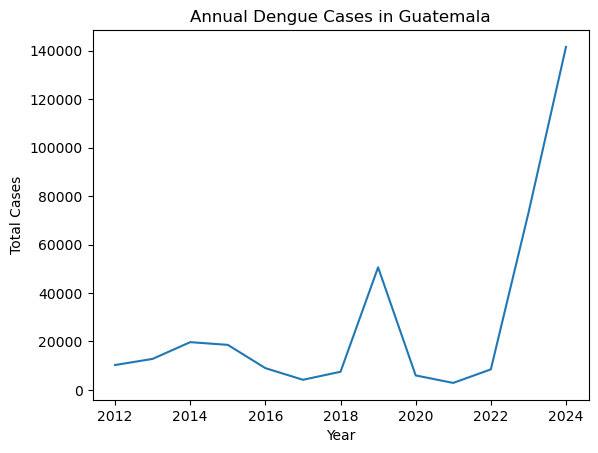

In [15]:
plt.plot(cases_by_year["year"], cases_by_year["total_cases"])
plt.title("Annual Dengue Cases in Guatemala")
plt.xlabel("Year")
plt.ylabel("Total Cases")
plt.show()

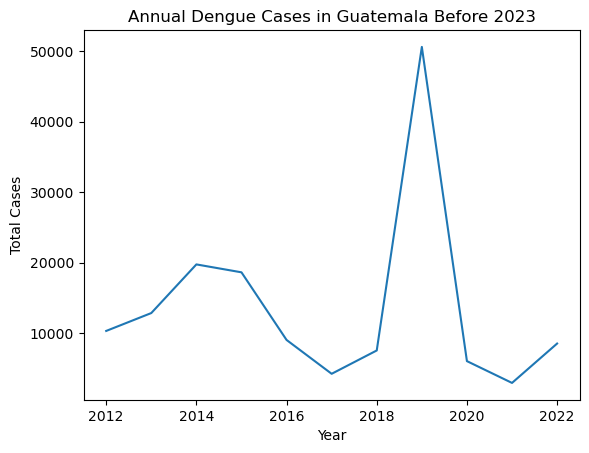

In [16]:
cases_before_2023 = cases_by_year[cases_by_year["year"] < 2023]

plt.plot(cases_before_2023["year"], cases_before_2023["total_cases"])

plt.title("Annual Dengue Cases in Guatemala Before 2023")

plt.xlabel("Year")

plt.ylabel("Total Cases")

plt.show()

(array([293.,  14.,   8.,   4.,   2.,   0.,   1.,   1.,   0.,   2.]),
 array([1.00000e+00, 2.26080e+03, 4.52060e+03, 6.78040e+03, 9.04020e+03,
        1.13000e+04, 1.35598e+04, 1.58196e+04, 1.80794e+04, 2.03392e+04,
        2.25990e+04]),
 <BarContainer object of 10 artists>)

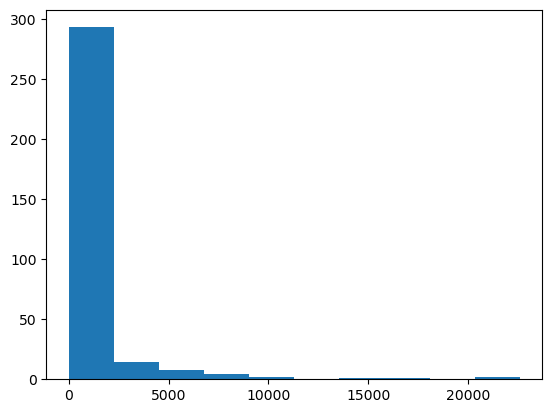

In [19]:
plt.hist(municipality['total_cases'])

## Top 10 Municipalities by Accumulated Dengue Cases (2012–2024)

In [22]:
top10 = year_municipality.groupby("municipality")["total_cases"].sum().sort_values(ascending=False).head(10)

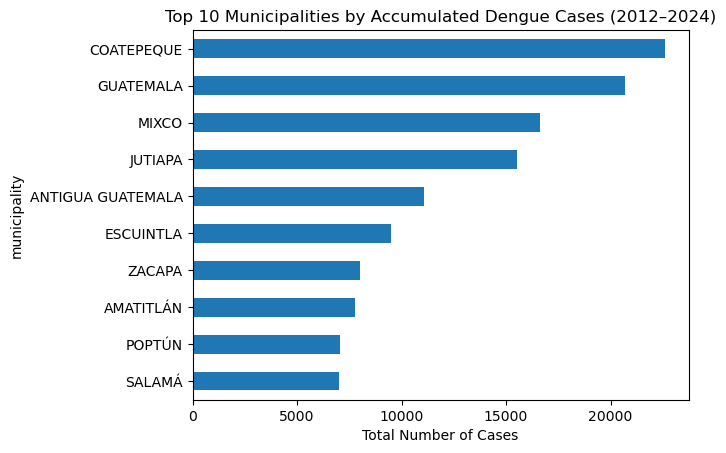

In [27]:
top10.plot(kind='barh')
plt.title("Top 10 Municipalities by Accumulated Dengue Cases (2012–2024)")
plt.xlabel("Total Number of Cases")
plt.gca().invert_yaxis()  # Invert y-axis to have the highest at the top
plt.show()

Several municipalities contribute substantially to the accumulated dengue burden, with case counts decreasing gradually among the top-ranked municipalities.

## Municipalities with high dengue cases across years

In [11]:
top10 = year_municipality.groupby("municipality")["total_cases"].sum().sort_values(ascending=False).head(10)
top10_municipalities = top10.index
top10_over_time = year_municipality[
    year_municipality["municipality"].isin(top10_municipalities)
]
top10_over_time

,year,municipality,total_cases
2,2012,AMATITLÁN,494
3,2012,ANTIGUA GUATEMALA,68
23,2012,COATEPEQUE,424
43,2012,ESCUINTLA,851
53,2012,GUATEMALA,141
...,...,...,...
2592,2024,JUTIAPA,8922
2611,2024,MIXCO,6280
2642,2024,POPTÚN,591
2655,2024,SALAMÁ,2381


In [14]:
top5 = year_municipality.groupby("municipality")["total_cases"].sum().sort_values(ascending=False).head(5)
top5_municipalities = top5.index
top5_over_time = year_municipality[
    year_municipality["municipality"].isin(top5_municipalities)
]
top5_over_time.head()

,year,municipality,total_cases
3,2012,ANTIGUA GUATEMALA,68
23,2012,COATEPEQUE,424
53,2012,GUATEMALA,141
64,2012,JUTIAPA,722
78,2012,MIXCO,71


In [15]:
top5_pivot = top5_over_time.pivot(index='year', columns='municipality', values='total_cases')
top5_pivot.head()

municipality,ANTIGUA GUATEMALA,COATEPEQUE,GUATEMALA,JUTIAPA,MIXCO
year,,,,,
2012,68,424,141,722,71
2013,181,547,512,407,334
2014,1065,1883,2048,210,681
2015,855,566,3148,18,2777
2016,939,93,1067,8,1230


<Axes: xlabel='year'>

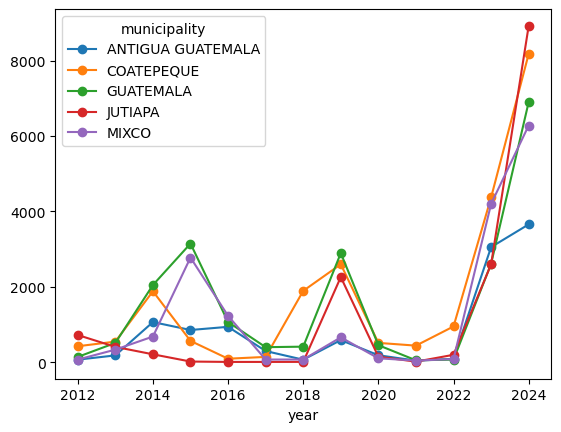

In [16]:
top5_pivot.plot(kind='line', marker='o')

In [24]:
year_municipality_renamed = year_municipality.rename(
    columns={"total_cases": "municipality_cases"}
)
year_totals_renamed = year_totals.rename(
    columns={"total_cases": "national_cases"}
)

In [ ]:
municipality_national_cases = pd.merge(year_municipality_renamed, year_totals_renamed, on="year")

,year,municipality,municipality_cases,national_cases
0,2012,AGUA BLANCA,2,10296
1,2012,ALOTENANGO,4,10296
2,2012,AMATITLÁN,494,10296
3,2012,ANTIGUA GUATEMALA,68,10296
4,2012,ASUNCIÓN MITA,31,10296
5,2012,ATESCATEMPA,18,10296
6,2012,AYUTLA,110,10296
7,2012,BARBERENA,9,10296
8,2012,CABAÑAS,8,10296
9,2012,CAHABÓN,2,10296
